In [1]:
# !pip install folium osmnx geopandas pandas shapely

import folium
import osmnx as ox
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
from datetime import datetime

In [2]:
### CONSTS ###
TRAFFIC_DIR = "../data/traffic"

LAT = 48.14553552490184
LNG = 17.114780288953938
MAP_ZOOM = 14
MAP_WIDTH = 2304
MAP_HEIGHT = 2304

START_TIME = datetime(2025, 1, 31, 2, 0)
END_TIME = datetime(2025, 1, 31, 20, 0)

In [3]:
from city_graph import build_road_graph, visualize_graph

G_major, nodes_major, edges_major = build_road_graph("Bratislava, Slovakia")

m = visualize_graph(nodes_major, edges_major)
m

Loaded 5 traffic images in selected interval.



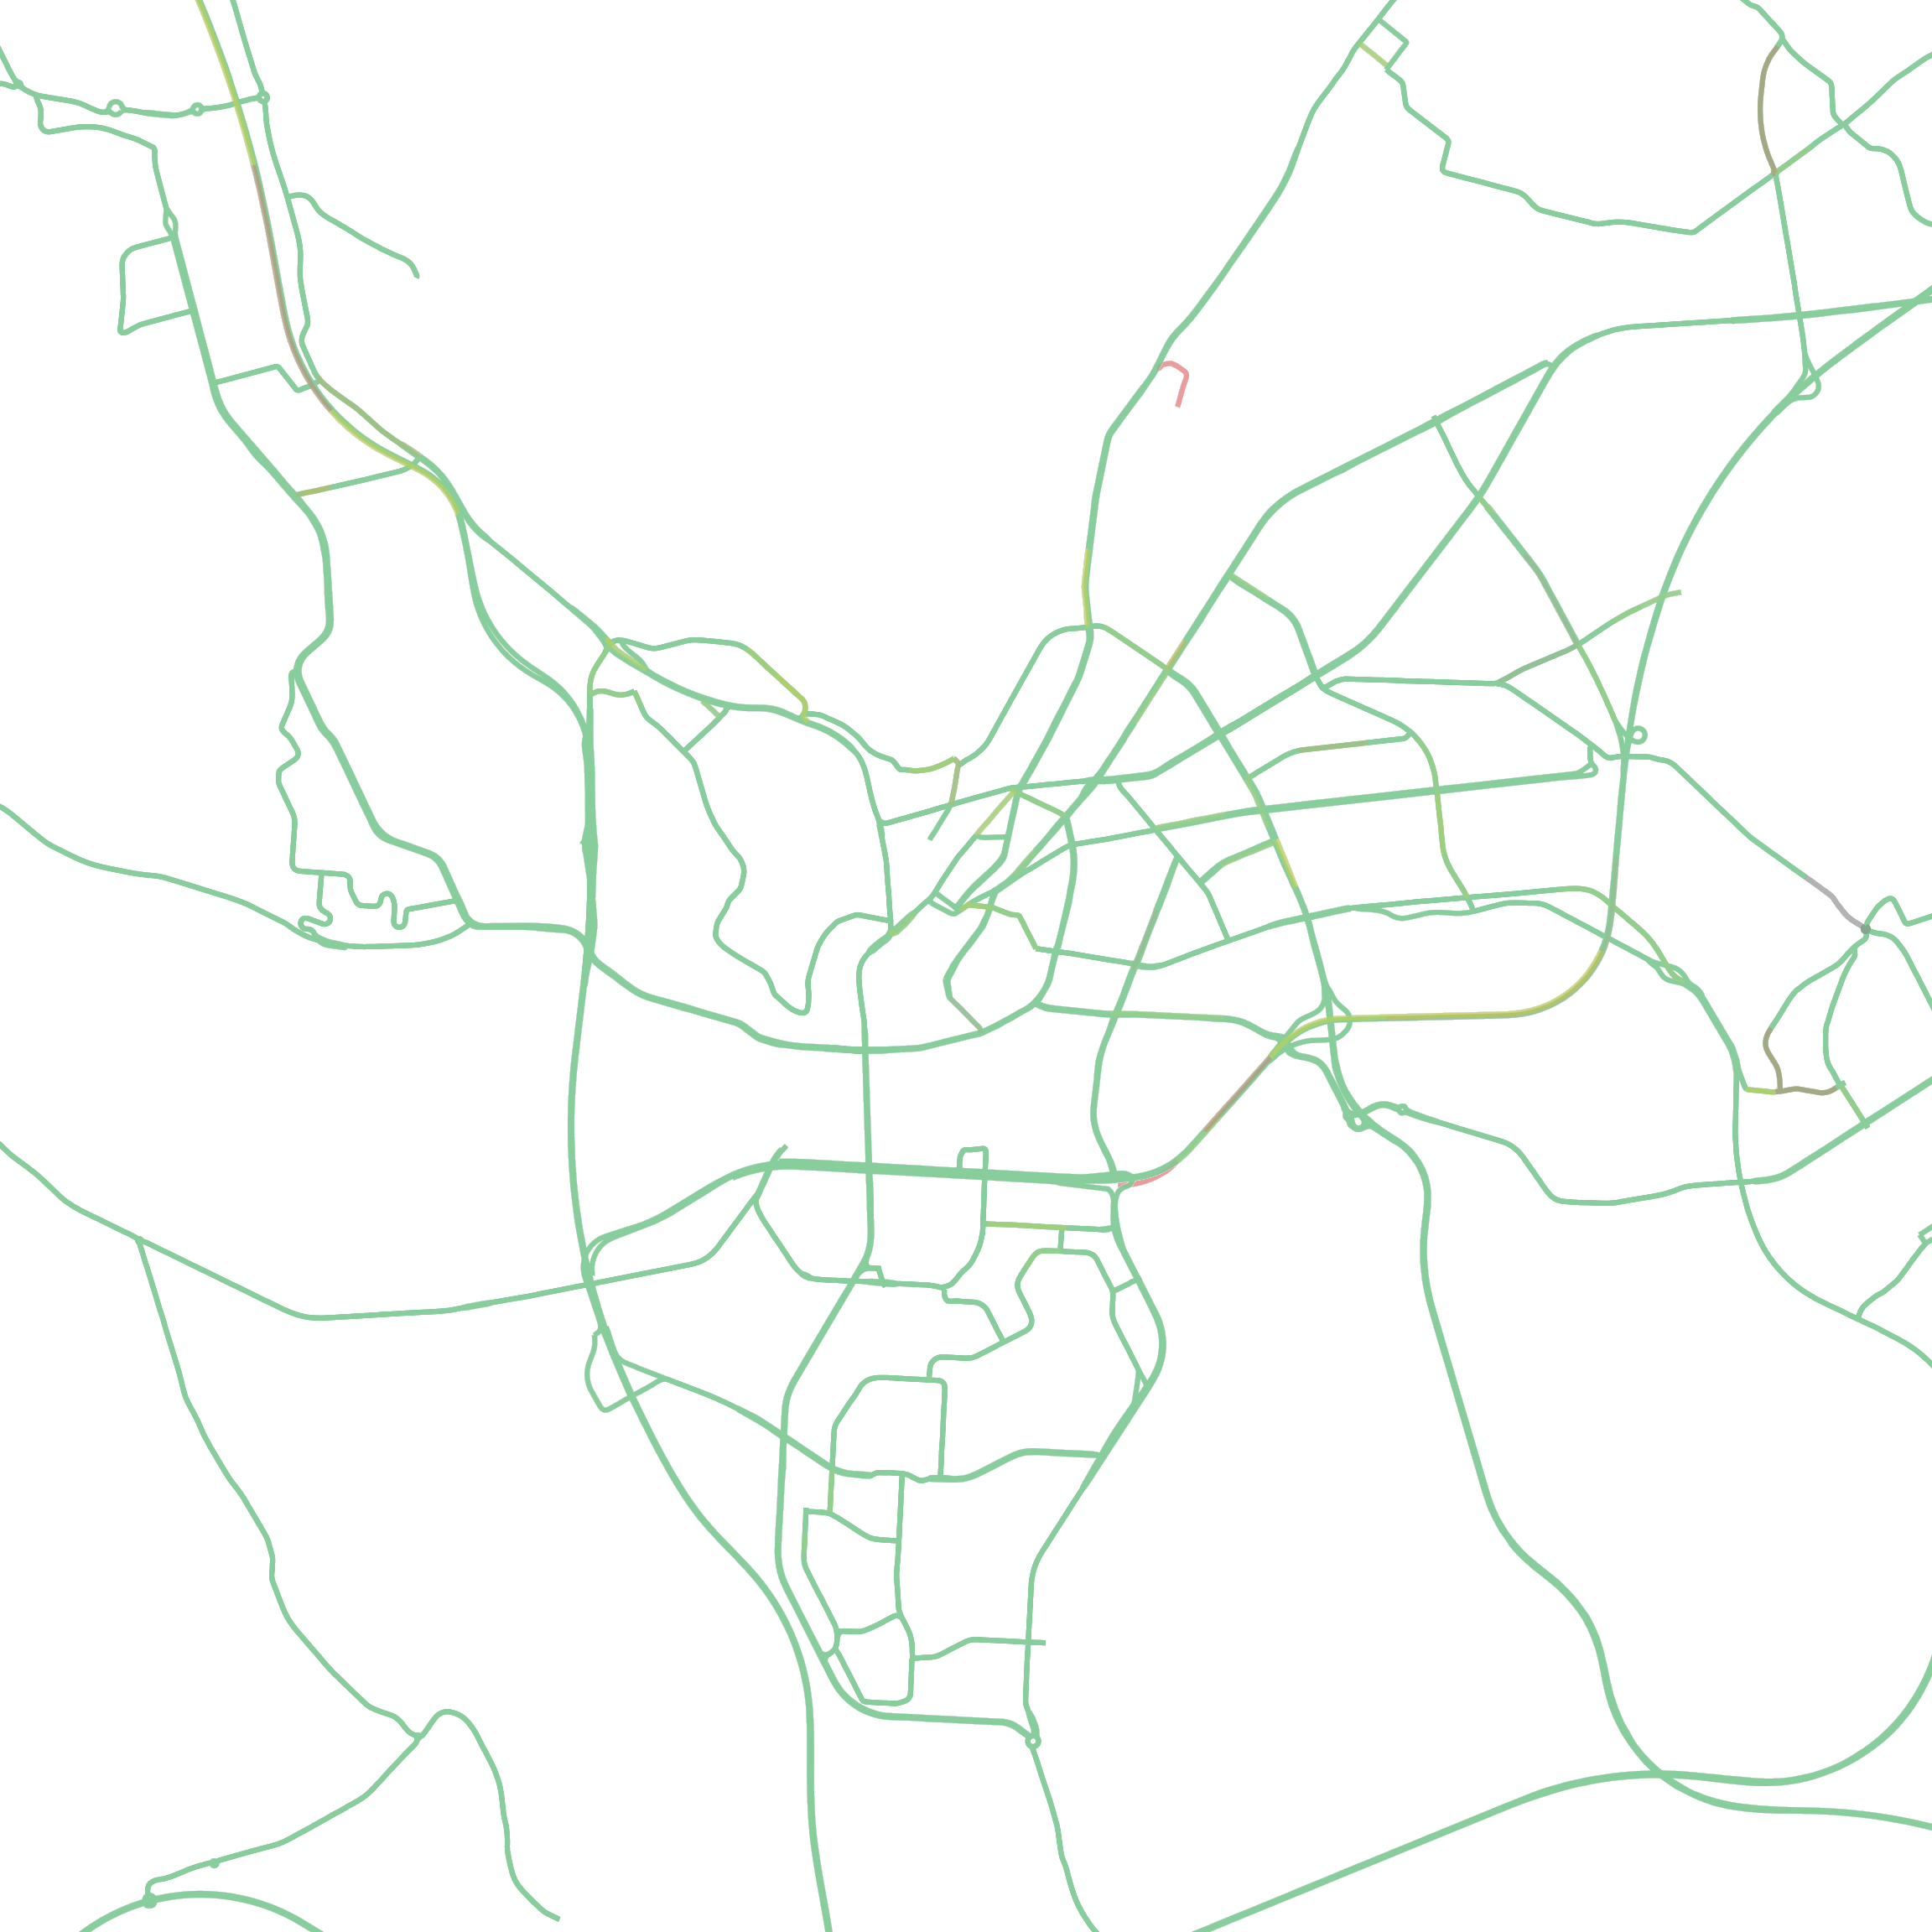

In [4]:
from traffic_data import build_traffic_raster, visualize_traffic_raster

aggregated_image = build_traffic_raster(
    folder=TRAFFIC_DIR, start_time=START_TIME, end_time=END_TIME
)

traffic_map = visualize_traffic_raster(
    aggregated_image=aggregated_image,
    center_lat=48.14553552490184,
    center_lng=17.114780288953938,
    zoom=14,
    width=2304,
    height=2304,
)
traffic_map

In [5]:
from traffic_graph import add_congestion_to_graph, visualize_weighted_graph


G_weighted = add_congestion_to_graph(
    graph=G_major,
    raster_image=aggregated_image,
    center_lat=LAT,
    center_lng=LNG,
    zoom=MAP_ZOOM,
    width=MAP_WIDTH,
    height=MAP_HEIGHT,
)
print(G_weighted)

map_congestion = visualize_weighted_graph(G_weighted, center_lat=LAT, center_lng=LNG)
map_congestion

MultiDiGraph with 1961 nodes and 2935 edges


In [6]:
from rsu.static_deployment import deploy_static_rsus
from rsu.visualize import visualize_rsu_deployment

NUM_RSUS = 100
COVERAGE_RADIUS = 300  # meters (urban DSRC approx)

rsu_nodes_static = deploy_static_rsus(
    graph=G_weighted, num_rsus=NUM_RSUS, coverage_radius_m=COVERAGE_RADIUS
)
print(rsu_nodes_static)

m = visualize_rsu_deployment(
    graph=G_weighted,
    rsu_nodes=rsu_nodes_static,
    center_lat=LAT,
    center_lng=LNG
)
m

[3323510294, 32030105, 36664497, 59719240, 1103688241, 21451595, 1005126118, 18049798, 685183750, 5432472415, 36665536, 32313709, 889348127, 27069352, 248611207, 2427858086, 4334481, 663093811, 12081497, 365276481, 17972923, 3556478559, 3700858010, 2396516152, 369554596, 26659811, 7847752074, 33590284, 946790619, 59720279, 11920081419, 1813037103, 28838480, 279537611, 248658613, 2358247733, 32122016, 59599212, 202869132, 31231557, 27349140, 8062845439, 2021200339, 20828297, 30700470, 2399507249, 51545282, 35454093, 299691758, 6690699, 59963078, 59720192, 698370540, 5411787, 981142949, 1305575796, 60391800, 183763401, 26673154, 2404036787, 202868760, 275537939, 79438144, 25532058, 270661849, 3149807614, 32858416, 26659813, 29505195, 271960789, 29537575, 26022156, 149131896, 30767153, 32198104, 1705143867, 32001450, 248631796, 25322524, 1201127, 279535995, 59994643, 259265570, 25920335, 21590580, 2696637897, 13028659621, 357949482, 9115364960, 1400994101, 419023289, 1078521560, 79466645,

In [ ]:
from evaluation import build_comparison_table
from traffic_data import calculate_image_bounds

bounds = calculate_image_bounds(LAT, LNG, MAP_ZOOM, MAP_WIDTH, MAP_HEIGHT)

deployments = {
    "static_traffic_strategy": rsu_nodes_static,
    #"topology_strategy": rsu_nodes_topology,
    #"hybrid_strategy": rsu_nodes_hybrid,
}

results = build_comparison_table(G_major, deployments, radius_m=300, raster_image=aggregated_image, bounds=bounds)

results

,num_rsus,node_coverage,road_coverage,avg_distance_to_rsu,redundancy,traffic_coverage,strategy
0,100,0.677715,0.567438,318.082985,0.036716,0.42443,traffic_strategy
